<a href="https://colab.research.google.com/github/Yaa-Waadu/AI-Final-Project/blob/main/ASL_Learning_Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

PyTorch version: 2.11.0+cu128
GPU available: True
Using: cuda


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/ASL_Project"

KAGGLE_DIR = os.path.join(PROJECT_DIR, "kaggle_dataset")
MY_IMAGES_DIR = os.path.join(PROJECT_DIR, "my_images")

print("Kaggle dataset:", KAGGLE_DIR)
print("My images:", MY_IMAGES_DIR)

Kaggle dataset: /content/drive/MyDrive/ASL_Project/kaggle_dataset
My images: /content/drive/MyDrive/ASL_Project/my_images


In [4]:
PROJECT_DIR = "/content/drive/MyDrive/ASL_Project"

print(os.listdir(PROJECT_DIR))

['Kaggle dataset', 'My images', 'best_asl_model.pth']


In [5]:
import os

PROJECT_DIR = "/content/drive/MyDrive/ASL_Project"

KAGGLE_DIR = os.path.join(PROJECT_DIR, "Kaggle dataset")
MY_IMAGES_DIR = os.path.join(PROJECT_DIR, "My images")

print("Kaggle folder exists:", os.path.exists(KAGGLE_DIR))
print("My images folder exists:", os.path.exists(MY_IMAGES_DIR))

Kaggle folder exists: True
My images folder exists: True


In [6]:
print("Kaggle dataset contents:")
print(os.listdir(KAGGLE_DIR))

Kaggle dataset contents:
['c', 'f', 'd', 'a', 'e', 'b', 'l', 'o', 'i', 'g', 'k', 'h', 'n', 'm', 'j', 'p', 'u', 'r', 't', 's', 'y', 'v', 'q', 'w', 'x', 'z']


In [7]:
classes = sorted([
    folder for folder in os.listdir(KAGGLE_DIR)
    if os.path.isdir(os.path.join(KAGGLE_DIR, folder))
])

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of classes: 26


In [8]:
for letter in sorted(os.listdir(MY_IMAGES_DIR)):
    folder_path = os.path.join(MY_IMAGES_DIR, letter)

    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(letter, ":", len(files), "image(s)")

a : 1 image(s)
b : 1 image(s)
c : 1 image(s)
d : 1 image(s)
e : 1 image(s)
f : 1 image(s)
g : 1 image(s)
h : 1 image(s)
i : 1 image(s)
j : 1 image(s)
k : 1 image(s)
l : 1 image(s)
m : 1 image(s)
n : 1 image(s)
o : 1 image(s)
p : 1 image(s)
q : 1 image(s)
r : 1 image(s)
s : 1 image(s)
t : 1 image(s)
u : 1 image(s)
v : 1 image(s)
w : 1 image(s)
x : 1 image(s)
y : 1 image(s)
z : 1 image(s)


In [9]:
for class_name in classes:
    class_path = os.path.join(KAGGLE_DIR, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{class_name}: {len(images)}")

a: 55
b: 55
c: 55
d: 55
e: 55
f: 55
g: 55
h: 55
i: 55
j: 55
k: 55
l: 55
m: 55
n: 55
o: 55
p: 55
q: 55
r: 55
s: 55
t: 50
u: 55
v: 55
w: 55
x: 55
y: 55
z: 55


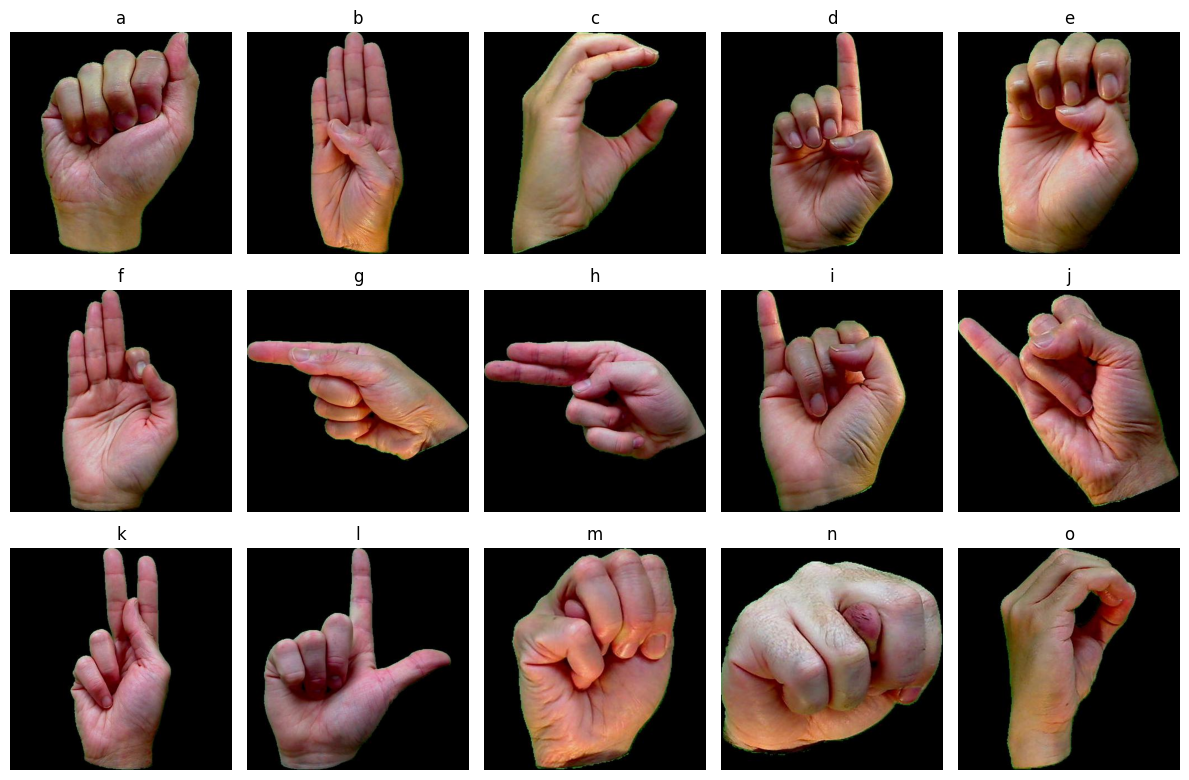

In [10]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for ax, class_name in zip(axes.flatten(), classes[:15]):
    class_path = os.path.join(KAGGLE_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, random.choice(image_files))

    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()